In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

from scipy.stats import binom
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'  
plt.rcParams['font.family'] = 'serif'



In [2]:
def energy_resolution_FWHM(sigma: float, mu: float) -> float:
    '''
    Computes the energy resolution (FWHM) of a Gaussian distribution given its standard deviation (sigma) and mean (mu).
    ======= params =======
    sigma, float: standard deviation of the Gaussian distribution
    mu, float: mean of the Gaussian distribution
    ======= returns =======
    FWHM, float: Full Width at Half Maximum of the Gaussian distribution
    '''
    return sigma * 2 *np.sqrt(2 * np.log(2)) / mu

def gaussian(x: float, A: float, sigma: float, mu: float) -> float:
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# 1. Lectura de los datos en chunks

El documento es demasiado grande como para leerlo todo conjunto en memoria, de forma que se abre en secciones.

In [3]:
path ='/Users/pablovazquez/GALA_hole/build/geometric_hits_absorbentGALA_3mm_testfullpeaks.txt'

In [4]:
usecols = ['event_id', 'time_ns', 'vx_mm', 'vy_mm', 'vz_mm', 'nPhotons']

chunksize = 200_000
sampling = 20

# Primera pasada: rango temporal global y radio máximo por evento
time_min = np.inf
time_max = -np.inf
radius_by_event = {}
photons_generated_by_event = {}
vz_by_event = {}

for chunk in pd.read_csv(path, sep=r'\s+', usecols = usecols, chunksize = chunksize):
    chunk['vR_mm'] = np.sqrt(chunk['vx_mm']**2 + chunk['vy_mm']**2)
    time_min = min(time_min, chunk['time_ns'].min())
    time_max = max(time_max, chunk['time_ns'].max())

    grouped = chunk.groupby('event_id', sort=False)
    max_radius = grouped['vR_mm'].max()
    for event_id, r_max in max_radius.items():
        radius_by_event[event_id] = max(radius_by_event.get(event_id, 0.0), float(r_max))
    
    # Guardar fotones generados (tomar el primero de cada evento, ya que es el mismo para todo el evento)
    n_photons = grouped['nPhotons'].first()
    for event_id, n_phot in n_photons.items():
        photons_generated_by_event[event_id] = int(n_phot)
    
    vz = grouped['vz_mm'].first()
    for event_id, z in vz.items():
        if event_id not in vz_by_event:
            vz_by_event[event_id] = float(z)

# Definir bins temporales globales
n_bins = int(np.ceil((time_max - time_min) / sampling))
bins = np.linspace(time_min, time_max, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Segunda pasada: construir conteos por evento y bin
per_event_bin_counts = {}
photons_by_event = {}
hist = np.zeros(n_bins, dtype=int)

for chunk in pd.read_csv(path, sep=r'\s+', usecols=usecols, chunksize=chunksize):
    try:
        chunk['vR_mm'] = np.sqrt(chunk['vx_mm']**2 + chunk['vy_mm']**2 + chunk['vz_mm']**2)
        chunk['bin_index'] = np.digitize(chunk['time_ns'], bins) - 1
        chunk = chunk[(chunk['bin_index'] >= 0) & (chunk['bin_index'] < n_bins)]

        hist += np.histogram(chunk['time_ns'].to_numpy(), bins=bins)[0]

        for (event_id, bin_index), group in chunk.groupby(['event_id', 'bin_index'], sort=False):
            event_bins = per_event_bin_counts.setdefault(int(event_id), np.zeros(n_bins, dtype=int))
            n_hits = int(len(group))
            event_bins[int(bin_index)] += n_hits
            photons_by_event[event_id] = photons_by_event.get(event_id, 0) + n_hits
    except Exception as e:
        print(f"Error processing chunk: {e}")
        continue

# Construir tabla resumida por evento para compatibilidad con el resto del notebook
sorted_event_ids = np.array(sorted(photons_by_event.keys()))
photons = np.array([photons_by_event[eid] for eid in sorted_event_ids])
radius = np.array([radius_by_event[eid] for eid in sorted_event_ids])
photons_generated = np.array([photons_generated_by_event.get(eid, 0) for eid in sorted_event_ids])

charge_binned = pd.DataFrame({
    'bin_center_ns': bin_centers,
    'n_hits': hist,
})

vz = np.array([vz_by_event.get(eid, np.nan) for eid in sorted_event_ids])

df_hits = pd.DataFrame({
    'event_id': sorted_event_ids,
    'photons': photons,
    'photons_generated': photons_generated,
    'radius': radius,
    'vz_mm': vz,
})
event_bin_rows = []
for event_id in sorted_event_ids:
    counts = per_event_bin_counts.get(int(event_id), np.zeros(n_bins, dtype=int))
    non_zero_bins = np.where(counts > 0)[0]
    for bin_index in non_zero_bins:
        event_bin_rows.append({
    'event_id': int(event_id),
    'bin_index': int(bin_index),
    'bin_center_ns': float(bin_centers[bin_index]),
    'n_hits': int(counts[bin_index]),
    'radius': float(radius_by_event[int(event_id)]),
    'vz_mm': float(vz_by_event.get(int(event_id), np.nan)),  # <-- añadir
})

event_bins_df = pd.DataFrame(event_bin_rows)

print(f'Hits/eventos procesados en chunks: {len(sorted_event_ids):,}')
print(f'Rango temporal global: {time_min:.6f} ns a {time_max:.6f} ns')
print(f'Hits totales acumulados: {hist.sum():,}')
print(f'Bins temporales: {n_bins:,}')
event_bins_df.head()

Hits/eventos procesados en chunks: 1,000
Rango temporal global: 7700.600000 ns a 16405.800000 ns
Hits totales acumulados: 46,977,681
Bins temporales: 436


,event_id,bin_index,bin_center_ns,n_hits,radius,vz_mm
0,0,49,8688.919725,1,0.397579,-0.815769
1,0,61,8928.512385,1,0.397579,-0.815769
2,0,65,9008.376606,1,0.397579,-0.815769
3,0,69,9088.240826,1,0.397579,-0.815769
4,0,75,9208.037156,1,0.397579,-0.815769


In [5]:
event_bins_df.event_id.nunique()

1000

In [6]:
energy = event_bins_df.groupby('event_id')['n_hits'].sum().reset_index(name='total_hits')

In [7]:
energy['z'] = event_bins_df.groupby('event_id')['vz_mm'].first().values

In [8]:
2.35*2000/37000

0.12702702702702703

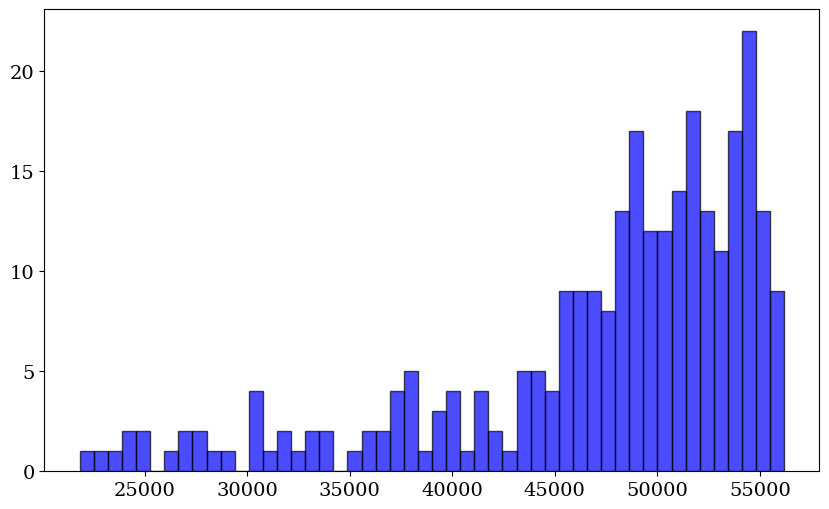

In [9]:
plt.hist(energy[np.abs(energy['z']) < 1]['total_hits'], bins=50, alpha=0.7, color='blue', edgecolor='black');

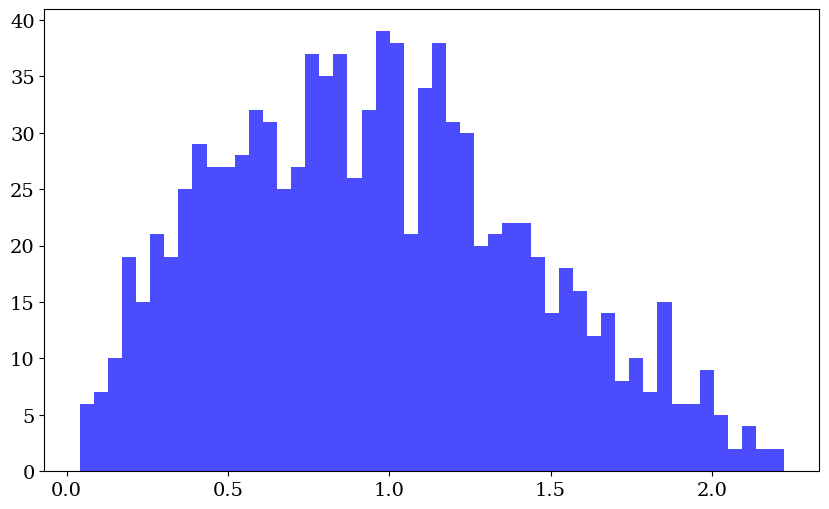

In [10]:
plt.hist(df_hits['radius'], bins=50, alpha=0.7, color='blue');

# 2. Cálculo de LCE

Definimos el número de fotones que se generan en el agujero de la GALA suponemos que una sigma del centro es lo que llega al agujero y tenemos en cuenta que para Xenon $W= 12.13\text{ eV}$ y el Kr genera $41.5 \text{ keV}$.

Cogemos los fotones generados en funcion de la distancia a la pared del agujero para entender los efectos de borde cerca de dicha pared

In [11]:
photons = df_hits['photons'].to_numpy()
radius = df_hits['radius'].to_numpy()
z = df_hits['vz_mm'].to_numpy()

In [12]:
df_hits

,event_id,photons,photons_generated,radius,vz_mm
0,0,54347,318077,0.397579,-0.815769
1,1,50468,316837,0.895471,-1.712320
2,2,51635,318143,0.797100,0.405335
3,3,26796,321500,1.880726,0.610207
4,4,38588,317011,1.562466,-1.307500
...,...,...,...,...,...
995,995,53111,317871,0.588243,-2.179310
996,996,44742,317089,1.228218,-2.067340
997,997,51696,315816,0.722226,-0.527058
998,998,52748,323117,0.765736,0.844182


In [13]:
# Calcular LCE (Light Collection Efficiency)
df_hits['lce'] = df_hits['photons'] / df_hits['photons_generated']

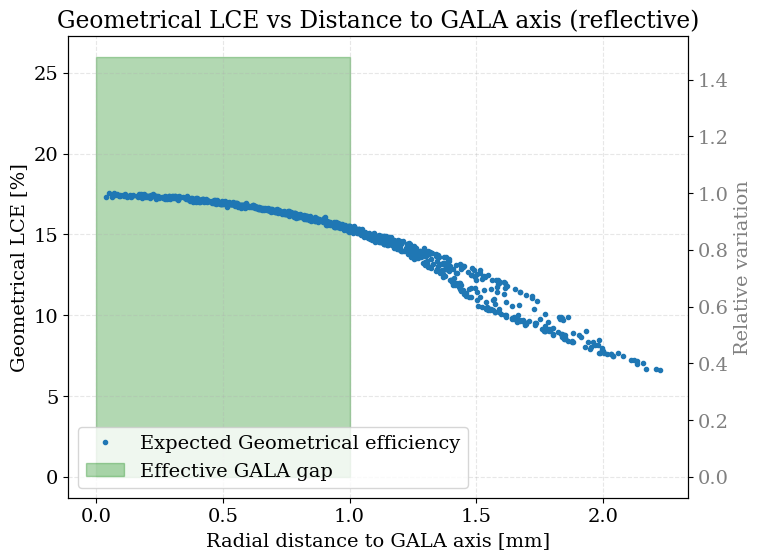

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(radius, df_hits.lce * 100, '.', label='Expected Geometrical efficiency')
ax1.fill_between((0, 1), (26, 26), alpha=0.3, color='green', label='Effective GALA gap')
ax1.set_title('Geometrical LCE vs Distance to GALA axis (reflective)')
ax1.set_xlabel('Radial distance to GALA axis [mm]')
ax1.set_ylabel('Geometrical LCE [%]')
ax1.grid(True, alpha=0.3, linestyle='--')

lce_max = df_hits.lce.max() * 100  # en %

ax2 = ax1.twinx()
ymin, ymax = ax1.get_ylim()
ax2.set_ylim(ymin / lce_max, ymax / lce_max)
ax2.set_ylabel('Relative variation', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='lower left')
plt.savefig('/Users/pablovazquez/GALA_hole/results/geometrical_lce_reflective.png')

Se observa, ya geométricamente aparece una pérdida de LCE por el ángulo sólido en funcion de cuanto te alejas del centro de la GALA (suponiendo reflexiones al 68% o 95% aparece una muy alta LCE).

# 3. Efectos de la electrónica

Aplico efectos de la electrónica (dark counts, crosstalk, pde y variación en la ganancia de los SiPM para poder entender como afectan estos a la medida de la resolución)

In [15]:
pde = 0.23
crosstalk_prob = 0.07
dark_count_rate_hz = 860000
microcells = 4774
gain_sigma_rel = 0.12
acquisition_window_ns = 1000.0

Dichos efectos de la electrónica se aplican por bin temporal.

In [16]:
np.exp(-3000/4774)

0.5334425739659133

In [17]:
def compute_pde_bin(event_bins_df, prob_pde=pde, prob_crosstalk=crosstalk_prob,
                    dark_noise=dark_count_rate_hz, gain_sigma_rel=gain_sigma_rel,
                    acquisition_window_ns=acquisition_window_ns,
                    rng=None):
    """
    Procesa los bins temporales de un evento y aplica todas las etapas de electrónica.

    Cada fila de `event_bins_df` representa un bin temporal del evento con:
    - event_id
    - bin_index
    - bin_center_ns
    - n_hits
    - radius

    Retorna una fila por bin con:
    - n_pde
    - n_crosstalk
    - n_dark
    - charge_pe
    """

    if rng is None:
        rng = np.random.default_rng()

    if event_bins_df.empty or 'n_hits' not in event_bins_df.columns:
        return pd.DataFrame(columns=[
            'event_id', 'bin_index', 'bin_center_ns', 'radius', 'n_hits',
            'n_pde', 'n_crosstalk', 'n_dark', 'n_after_ct', 'n_after_dark', 'charge_pe'
        ])

    rows = []
    event_id = int(event_bins_df['event_id'].iloc[0])
    radius = float(event_bins_df['radius'].iloc[0])
    vz_mm = float(event_bins_df['vz_mm'].iloc[0])
    dark_mean = dark_noise * acquisition_window_ns * 1e-9

    for _, row in event_bins_df.sort_values('bin_index').iterrows():
        n_hits = int(row['n_hits'])
        bin_index = int(row['bin_index'])
        bin_center_ns = float(row['bin_center_ns'])

        n_hits = rng.binomial(n_hits, 1)
        n_pde = min(rng.binomial(n_hits, prob_pde), microcells)
        n_crosstalk = rng.binomial(n_pde, prob_crosstalk)
        n_after_ct = min(n_pde + n_crosstalk, microcells)
        n_dark = rng.poisson(dark_mean)
        n_after_dark = min(n_after_ct + n_dark, microcells)
        k = n_after_dark/sampling/microcells
        correction = 1/(1+k*20)
        n_seen = n_after_dark * correction



        sigma_gain = gain_sigma_rel * np.sqrt(max(n_seen, 1))
        charge_pe = float(n_seen + rng.normal(0.0, sigma_gain))
        if charge_pe < 0.0:
            charge_pe = 0.0

        rows.append({
            'event_id': event_id,
            'bin_index': bin_index,
            'bin_center_ns': bin_center_ns,
            'radius': radius,
            'vz_mm': vz_mm,
            'n_hits': n_hits,
            'n_pde': n_pde,
            'n_crosstalk': n_crosstalk,
            'n_dark': n_dark,
            'n_after_ct': n_after_ct,
            'n_after_dark': n_after_dark,
            'charge_pe': charge_pe,
        })

    return pd.DataFrame(rows)

In [18]:
event_bins_df

,event_id,bin_index,bin_center_ns,n_hits,radius,vz_mm
0,0,49,8688.919725,1,0.397579,-0.815769
1,0,61,8928.512385,1,0.397579,-0.815769
2,0,65,9008.376606,1,0.397579,-0.815769
3,0,69,9088.240826,1,0.397579,-0.815769
4,0,75,9208.037156,1,0.397579,-0.815769
...,...,...,...,...,...,...
291784,999,367,15038.125229,1,1.451315,-2.029180
291785,999,379,15277.717890,1,1.451315,-2.029180
291786,999,380,15297.683945,2,1.451315,-2.029180
291787,999,384,15377.548165,1,1.451315,-2.029180


In [19]:
rng_electronics = np.random.default_rng()
resultados_electronica = []

for event_id, event_bins_df in event_bins_df.groupby('event_id', sort=True):
    event_result = compute_pde_bin(
        event_bins_df,
        prob_pde=pde,
        prob_crosstalk=crosstalk_prob,
        dark_noise=dark_count_rate_hz,
        gain_sigma_rel=gain_sigma_rel,
        acquisition_window_ns=acquisition_window_ns,
        rng=rng_electronics,
    )
    resultados_electronica.append(event_result)

charge_binned_electronica = pd.concat(resultados_electronica, ignore_index=True)
print(f'Eventos procesados: {charge_binned_electronica["event_id"].nunique():,}')
print(f'Filas bin-evento procesadas: {len(charge_binned_electronica):,}')
charge_binned_electronica.head()

Eventos procesados: 1,000
Filas bin-evento procesadas: 291,789


,event_id,bin_index,bin_center_ns,radius,vz_mm,n_hits,n_pde,n_crosstalk,n_dark,n_after_ct,n_after_dark,charge_pe
0,0,49,8688.919725,0.397579,-0.815769,1,0,0,1,0,1,0.976089
1,0,61,8928.512385,0.397579,-0.815769,1,0,0,0,0,0,0.073555
2,0,65,9008.376606,0.397579,-0.815769,1,1,0,0,1,1,1.175370
3,0,69,9088.240826,0.397579,-0.815769,1,0,0,0,0,0,0.000000
4,0,75,9208.037156,0.397579,-0.815769,1,1,0,0,1,1,1.054929


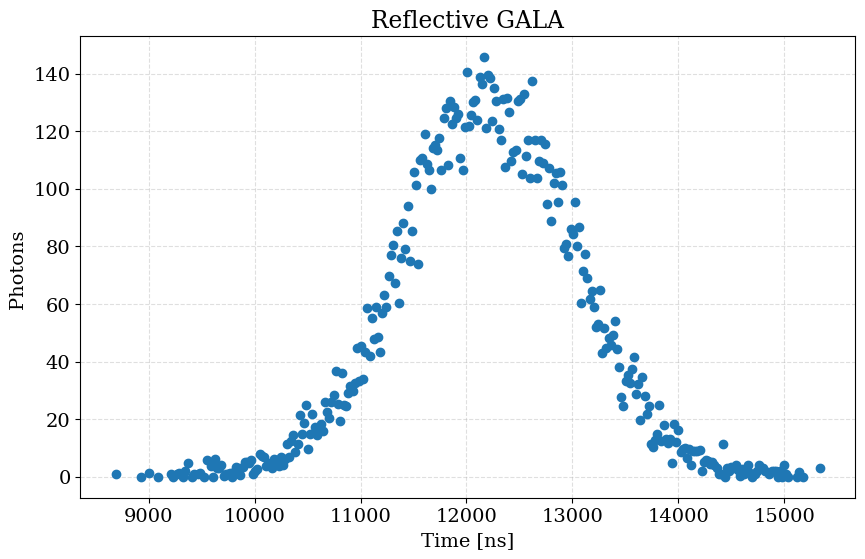

In [20]:
plt.plot(charge_binned_electronica[charge_binned_electronica.event_id==0].bin_center_ns, charge_binned_electronica[charge_binned_electronica.event_id==0]['charge_pe'], 'o');
plt.xlabel('Time [ns]');
plt.ylabel('Photons ');
plt.annotate('500 ns sampling', xy = (9200, 1200), )
plt.annotate('4774 microcells', xy = (9200, 950))
plt.title('Reflective GALA')
plt.grid(True, alpha = 0.4, linestyle = '--')
plt.savefig('/Users/pablovazquez/GALA_hole/results/reflective_500ns_sampling_signal.png')

In [21]:
np.max(charge_binned_electronica[charge_binned_electronica.event_id==0]['charge_pe'])

145.82588221438155

In [22]:
# Carga total por evento (sumando bins)
event_summary = (
    charge_binned_electronica
    .groupby('event_id', as_index=False)
    .agg(
        radius=('radius', 'first'),
        z_position=('vz_mm', 'first'),
        charge_pe=('charge_pe', 'sum'),
        n_hits=('n_hits', 'sum'),
        n_pde=('n_pde', 'sum'),
        n_crosstalk=('n_crosstalk', 'sum'),
        n_dark=('n_dark', 'sum'),
    )
)

charge_collection = event_summary['charge_pe'].to_list()
charge_collection_center = event_summary.loc[event_summary['radius'] < 0.9, 'charge_pe'].to_list()
charge_collection_center_1 = event_summary.loc[event_summary['radius'] < 1, 'charge_pe'].to_list()
charge_collection_center_2 = event_summary.loc[event_summary['radius'] < 0.6, 'charge_pe'].to_list()
charge_collection_center_3 = event_summary.loc[event_summary['radius'] < 1.2, 'charge_pe'].to_list()
charge_collection_center_4 = event_summary.loc[event_summary['radius'] < 1.4, 'charge_pe'].to_list()
charge_collection_center_5 = event_summary.loc[event_summary['radius'] < 0.5, 'charge_pe'].to_list()
charge_collection_center_6 = event_summary.loc[event_summary['radius'] < 0.7, 'charge_pe'].to_list()
charge_collection_center_7 = event_summary.loc[event_summary['radius'] < 0.8, 'charge_pe'].to_list()

print(f'Eventos totales: {len(charge_collection)}')
print(f'Eventos con radius < 0.7 mm: {len(charge_collection_center)}')

Eventos totales: 1000
Eventos con radius < 0.7 mm: 470


In [23]:
event_summary

,event_id,radius,z_position,charge_pe,n_hits,n_pde,n_crosstalk,n_dark
0,0,0.397579,-0.815769,13366.905679,54347,12486,869,274
1,1,0.895471,-1.712320,12428.416242,50468,11590,801,248
2,2,0.797100,0.405335,12750.378297,51635,11893,825,265
3,3,1.880726,0.610207,6793.932831,26796,6133,460,272
4,4,1.562466,-1.307500,9665.147221,38588,8891,650,260
...,...,...,...,...,...,...,...,...
995,995,0.588243,-2.179310,12973.557055,53111,12136,834,258
996,996,1.228218,-2.067340,11079.829490,44742,10292,717,247
997,997,0.722226,-0.527058,12690.028603,51696,11812,849,267
998,998,0.765736,0.844182,12993.110293,52748,12122,874,259


In [24]:
event_summary.charge_pe/df_hits.photons_generated

0      0.042024
1      0.039227
2      0.040078
3      0.021132
4      0.030488
         ...   
995    0.040814
996    0.034942
997    0.040182
998    0.040212
999    0.028117
Length: 1000, dtype: float64

In [25]:
data_mapa = pd.DataFrame({'Z': event_summary.z_position, 'R': event_summary.radius, 'LCE': event_summary.charge_pe/df_hits.photons_generated})

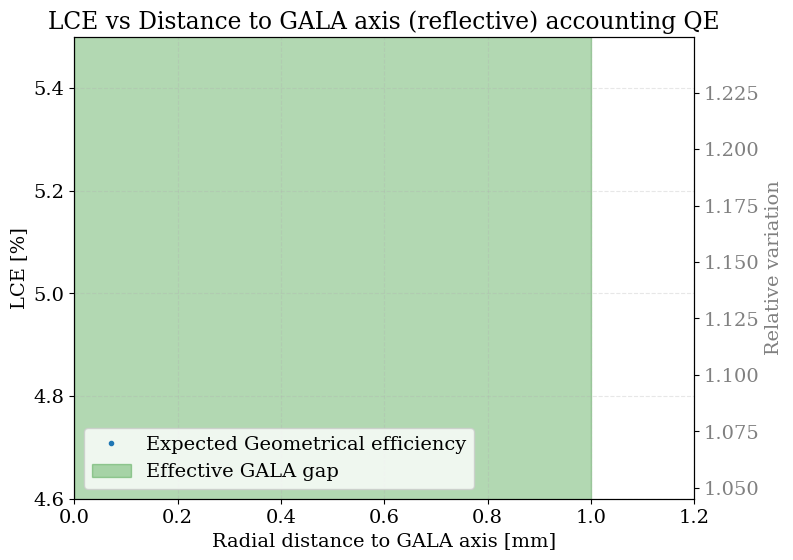

In [26]:
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(radius, event_summary.charge_pe/df_hits.photons_generated*100, '.', label='Expected Geometrical efficiency')
ax1.fill_between((0, 1), (7, 7), alpha=0.3, color='green', label='Effective GALA gap')
ax1.set_title('LCE vs Distance to GALA axis (reflective) accounting QE')
ax1.set_xlabel('Radial distance to GALA axis [mm]')
ax1.set_ylabel('LCE [%]')
ax1.set_ylim(4.6, 5.5)
ax1.set_xlim(0, 1.2)
ax1.grid(True, alpha=0.3, linestyle='--')


lce_max = np.max(event_summary.charge_pe/df_hits.photons_generated*100)

ax2 = ax1.twinx()
ymin, ymax = ax1.get_ylim()
ax2.set_ylim(ymin / lce_max, ymax / lce_max)
ax2.set_ylabel('Relative variation', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='lower left')
plt.savefig('/Users/pablovazquez/GALA_hole/results/total_lce_reflective.png')

In [35]:
counts, bins = np.histogram(charge_collection_center, bins = 20)
bincents = (bins[:-1] + bins[1:]) / 2

In [36]:
xplot = np.linspace(bincents[0], bincents[-1] + 30, 1000)

In [37]:
popt, pcov = curve_fit(gaussian, bincents, counts, p0 = (400, 200, 13000))

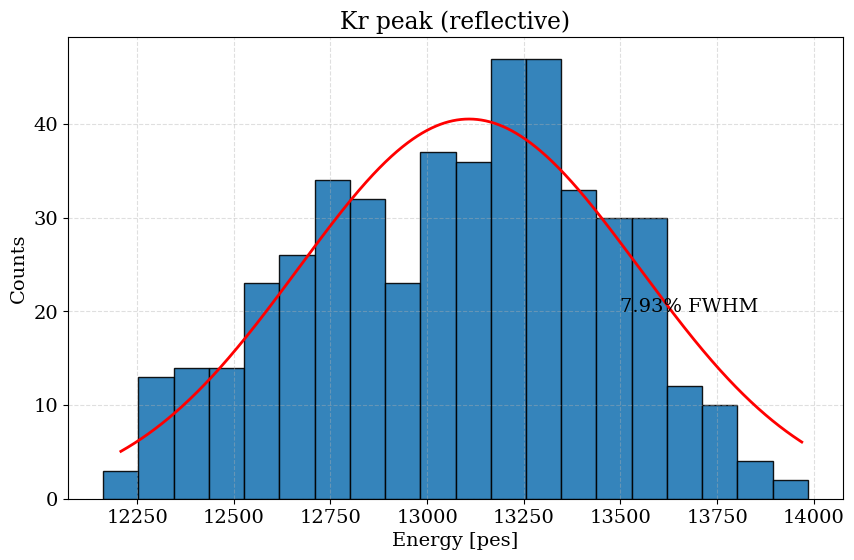

In [38]:
plt.hist(charge_collection_center, bins = 20, alpha = .9, edgecolor = 'black');
plt.plot(xplot, gaussian(xplot, *popt), 'r-', linewidth=2);
plt.annotate(f'{np.abs(energy_resolution_FWHM(popt[1], popt[2]))*100:.2f}% FWHM', xy = (13500, 20))
# plt.xlim(3750, 4700)
plt.xlabel('Energy [pes]');
plt.ylabel('Counts');
plt.grid(True, alpha = 0.4, linestyle='--');
plt.title('Kr peak (reflective)');
plt.savefig('/Users/pablovazquez/GALA_hole/results/Energy_resolution_reflective.png')

In [31]:
charge_collections = [charge_collection_center, charge_collection_center_1, charge_collection_center_2, charge_collection_center_3, charge_collection_center_4, charge_collection_center_5, charge_collection_center_6, charge_collection_center_7]
effective_gap = [0.9, 1, 0.6, 1.2, 1.4, 0.5, 0.7, 0.8]
resolutions = []

for cc in charge_collections:
    counts, bins = np.histogram(cc, bins = 20)
    bincents = (bins[:-1] + bins[1:]) / 2
    popt, pcov = curve_fit(gaussian, bincents, counts, p0 = (400, 200,13000))
    resolutions.append(energy_resolution_FWHM(popt[1], popt[2])*100)


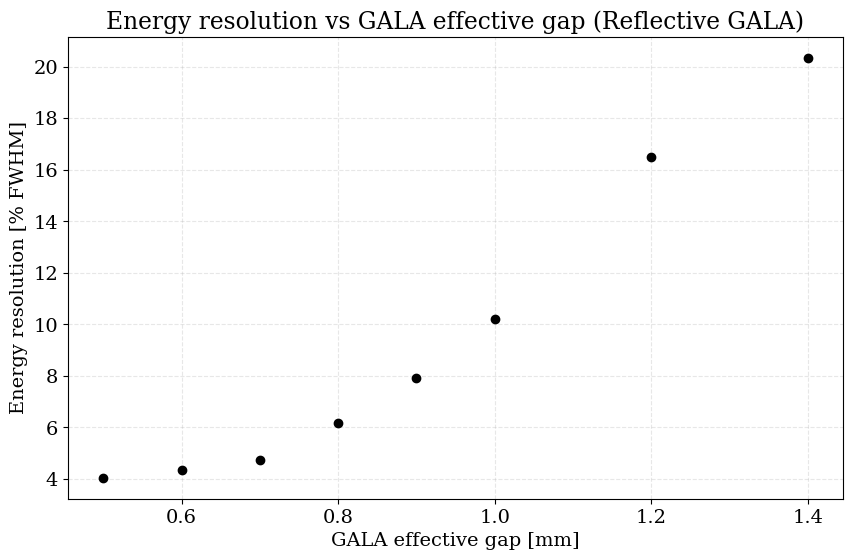

In [32]:
plt.plot(effective_gap, np.abs(resolutions), 'ko')
plt.xlabel('GALA effective gap [mm]');
plt.ylabel('Energy resolution [% FWHM]');
plt.title('Energy resolution vs GALA effective gap (Reflective GALA)');
plt.grid(True, alpha = 0.3, linestyle = '--')
plt.savefig('/Users/pablovazquez/GALA_hole/results/energy_resolution_vs_effective_gap_reflective.png')